<a href="https://colab.research.google.com/github/revathi4514kiet-del/536363/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

# Make NumPy output easier to read
np.set_printoptions(precision=4, suppress=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ============================================seen ================
# CELL 2: PROJECT INPUTS
# ============================================================

# City names
cities = ["City A", "City B", "City C"]

# Initial population of each city
initial_population = np.array([
    500000,   # City A
    300000,   # City B
    200000    # City C
], dtype=float)

# ------------------------------------------------------------
# MIGRATION RATES
#
# migration_rate[from_city][to_city]
#
# Example:
# 0.10 means 10% of the population of that city
# moves to the destination city per year.
# ------------------------------------------------------------

migration_rate = np.array([
    [0.00, 0.05, 0.10],   # From City A -> A,B,C
    [0.10, 0.00, 0.05],   # From City B -> A,B,C
    [0.05, 0.10, 0.00]    # From City C -> A,B,C
])

# Number of years for prediction
n_years = 10

print("Cities:", cities)
print("Initial population:", initial_population)
print("Migration-rate matrix:")
print(migration_rate)
print("Prediction period:", n_years, "years")

Cities: ['City A', 'City B', 'City C']
Initial population: [500000. 300000. 200000.]
Migration-rate matrix:
[[0.   0.05 0.1 ]
 [0.1  0.   0.05]
 [0.05 0.1  0.  ]]
Prediction period: 10 years


In [ ]:
# ============================================================
# CELL 3: INPUT VALIDATION
# ============================================================

def validate_inputs(cities, initial_population, migration_rate):
    """
    Check whether the project inputs are mathematically valid.
    """

    # Check number of cities
    if len(cities) != 3:
        raise ValueError("This project requires exactly 3 cities.")

    # Check population values
    if len(initial_population) != 3:
        raise ValueError("Enter population for all 3 cities.")

    if np.any(initial_population < 0):
        raise ValueError("Population cannot be negative.")

    # Check migration matrix shape
    if migration_rate.shape != (3, 3):
        raise ValueError("Migration matrix must be 3 x 3.")

    # Rates must be between 0 and 1
    if np.any(migration_rate < 0) or np.any(migration_rate > 1):
        raise ValueError("Migration rates must be between 0 and 1.")

    # No self-migration rates are required
    for i in range(3):
        if migration_rate[i, i] != 0:
            raise ValueError(
                "Diagonal migration rates should be 0. "
                "The staying percentage is calculated automatically."
            )

    # Total outgoing migration cannot exceed 100%
    for i in range(3):
        if np.sum(migration_rate[i, :]) > 1:
            raise ValueError(
                f"Outgoing migration from {cities[i]} exceeds 100%."
            )

    print("Input validation successful!")


validate_inputs(
    cities,
    initial_population,
    migration_rate
)

Input validation successful!


In [ ]:
# ============================================================
# CELL 4: CONSTRUCT MIGRATION MATRIX M
# ============================================================

def build_migration_matrix(migration_rate):
    """
    Convert migration rates into a column-stochastic
    migration matrix M.

    M[i,j] = fraction of population moving
             from city j to city i.
    """

    M = np.zeros((3, 3))

    # Fill off-diagonal migration values.
    #
    # migration_rate[j,i] means:
    # population moving FROM city j TO city i.
    for from_city in range(3):
        for to_city in range(3):

            if from_city != to_city:
                M[to_city, from_city] = migration_rate[from_city, to_city]

    # Calculate the percentage staying in each city.
    for city in range(3):
        outgoing_migration = np.sum(migration_rate[city, :])
        M[city, city] = 1 - outgoing_migration

    return M


M = build_migration_matrix(migration_rate)

print("Migration Matrix M:")
print(M)

print("\nColumn sums:")
print(M.sum(axis=0))

Migration Matrix M:
[[0.85 0.1  0.05]
 [0.05 0.85 0.1 ]
 [0.1  0.05 0.85]]

Column sums:
[1. 1. 1.]


In [ ]:
# ============================================================
# CELL 5: MATHEMATICAL MODEL
# ============================================================

M_sym = sp.Matrix(M)

print("Migration Matrix M:")
sp.pprint(M_sym)

print("\nPopulation model:")
print("P(n+1) = M P(n)")

print("\nTherefore:")
print("P(n) = M^n P(0)")

print("\nFor diagonalization:")
print("M = P D P^(-1)")

print("\nTherefore:")
print("M^n = P D^n P^(-1)")

Migration Matrix M:
⎡0.85  0.1   0.05⎤
⎢                ⎥
⎢0.05  0.85  0.1 ⎥
⎢                ⎥
⎣0.1   0.05  0.85⎦

Population model:
P(n+1) = M P(n)

Therefore:
P(n) = M^n P(0)

For diagonalization:
M = P D P^(-1)

Therefore:
M^n = P D^n P^(-1)


In [ ]:
# ============================================================
# CELL 6: INITIAL POPULATION VECTOR
# ============================================================

P0 = sp.Matrix(initial_population)

print("Initial population vector P(0):")
sp.pprint(P0)

print("\nTotal initial population:")
print(f"{initial_population.sum():,.0f}")

Initial population vector P(0):
⎡500000.0⎤
⎢        ⎥
⎢300000.0⎥
⎢        ⎥
⎣200000.0⎦

Total initial population:
1,000,000


In [ ]:
# ============================================================
# CELL 7: DIAGONALIZATION
# ============================================================

print("Eigenvalues of M:")
eigenvalues = M_sym.eigenvals()

for value, multiplicity in eigenvalues.items():
    print(f"Eigenvalue = {sp.N(value, 6)}, multiplicity = {multiplicity}")


# Get eigenvectors
eigenvectors = M_sym.eigenvects()

print("\nEigenvectors:")
for eigenvalue, multiplicity, vectors in eigenvectors:
    print(f"\nEigenvalue: {sp.N(eigenvalue, 6)}")
    for vector in vectors:
        sp.pprint(vector)


# Diagonalization
P, D = M_sym.diagonalize()

print("\nMatrix P:")
sp.pprint(P)

print("\nMatrix D:")
sp.pprint(D)

print("\nCheck:")
print("M = P D P^(-1)")

Eigenvalues of M:
Eigenvalue = 1.0 - 4.93879e-33*I, multiplicity = 1
Eigenvalue = 0.775 - 0.0433013*I, multiplicity = 1
Eigenvalue = 0.775 + 0.0433013*I, multiplicity = 1

Eigenvectors:

Eigenvalue: 1.0 - 4.93879e-33*I
⎡-0.486135871237332 + 0.311456655137843⋅ⅈ⎤
⎢                                        ⎥
⎢-0.486135871237332 + 0.311456655137843⋅ⅈ⎥
⎢                                        ⎥
⎣-0.486135871237332 + 0.311456655137843⋅ⅈ⎦

Eigenvalue: 0.775 - 0.0433013*I
⎡0.183424832137148 - 0.547438274409812⋅ⅈ ⎤
⎢                                        ⎥
⎢-0.565807868711388 + 0.114868572889239⋅ⅈ⎥
⎢                                        ⎥
⎣0.382383036574239 + 0.432569701520573⋅ⅈ ⎦

Eigenvalue: 0.775 + 0.0433013*I
⎡0.559899742697376 + 0.140874452832108⋅ⅈ ⎤
⎢                                        ⎥
⎢-0.401950726245526 + 0.414450174332244⋅ⅈ⎥
⎢                                        ⎥
⎣-0.157949016451849 - 0.555324627164352⋅ⅈ⎦

Matrix P:
⎡-0.486135871237332 + 0.311456655137843⋅ⅈ  0.18342483213714

In [ ]:
# ============================================================
# CELL 8: CALCULATE M^n USING DIAGONALIZATION
# ============================================================

def matrix_power_by_diagonalization(M_sym, P, D, n):
    """
    Calculate M^n using:

        M^n = P D^n P^(-1)
    """

    D_n = D ** n

    M_n = P * D_n * P.inv()

    return sp.simplify(M_n)


M_n = matrix_power_by_diagonalization(
    M_sym,
    P,
    D,
    n_years
)

print(f"M^{n_years}:")
sp.pprint(M_n)

M^10:
⎡0.378229786302051 + 5.03069808033274e-17⋅ⅈ  0.335161507886523 - 2.08166817117 ↪
⎢                                                                              ↪
⎢0.286608705811426 + 5.55111512312578e-17⋅ⅈ  0.378229786302051 - 3.46944695195 ↪
⎢                                                                              ↪
⎣0.335161507886523 + 5.55111512312578e-17⋅ⅈ  0.286608705811426 - 3.12250225675 ↪

↪ 217e-17⋅ⅈ  0.286608705811426 - 2.77555756156289e-17⋅ⅈ⎤
↪                                                      ⎥
↪ 361e-17⋅ⅈ  0.335161507886523 - 2.42861286636753e-17⋅ⅈ⎥
↪                                                      ⎥
↪ 825e-17⋅ⅈ  0.378229786302051 - 2.60208521396521e-17⋅ⅈ⎦


In [ ]:
# ============================================================
# CELL 9: POPULATION AFTER n YEARS
# ============================================================

# P0 = initial population column vector
P0 = sp.Matrix([float(x) for x in initial_population])

# Calculate population using diagonalization:
# M^n = P D^n P^(-1)
P_n = M_n * P0

print(f"Population after {n_years} years:")
print("-" * 45)

for i, city in enumerate(cities):

    # Convert possible complex value into Python complex number
    value = complex(sp.N(P_n[i]))

    # The actual population is real.
    # Remove only the tiny numerical imaginary component.
    population = value.real

    print(f"{city}: {population:,.2f}")

print("-" * 45)

# Total population
total_after_n_years = sum(
    complex(sp.N(P_n[i])).real
    for i in range(3)
)

print(f"Total population: {total_after_n_years:,.2f}")

Population after 10 years:
---------------------------------------------
City A: 346,985.09
City B: 323,805.59
City C: 329,209.32
---------------------------------------------
Total population: 1,000,000.00


In [ ]:
# ============================================================
# CELL 10: VERIFY DIAGONALIZATION RESULT
# ============================================================

direct_M_n = M_sym ** n_years

difference = sp.simplify(M_n - direct_M_n)

print("Difference between:")
print("1. Diagonalization method")
print("2. Direct matrix power")

sp.pprint(difference)

if difference == sp.zeros(3):
    print("\n✓ Verification successful!")
    print("Both methods give exactly the same M^n.")
else:
    print("\nSmall numerical/symbolic difference detected.")

Difference between:
1. Diagonalization method
2. Direct matrix power
⎡2.77555756156289e-16 + 5.03069808033274e-17⋅ⅈ  5.55111512312578e-17 - 2.08166 ↪
⎢                                                                              ↪
⎢2.22044604925031e-16 + 5.55111512312578e-17⋅ⅈ  2.77555756156289e-16 - 3.46944 ↪
⎢                                                                              ↪
⎣1.66533453693773e-16 + 5.55111512312578e-17⋅ⅈ  1.11022302462516e-16 - 3.12250 ↪

↪ 817117217e-17⋅ⅈ  5.55111512312578e-17 - 2.77555756156289e-17⋅ⅈ⎤
↪                                                               ⎥
↪ 695195361e-17⋅ⅈ  5.55111512312578e-17 - 2.42861286636753e-17⋅ⅈ⎥
↪                                                               ⎥
↪ 225675825e-17⋅ⅈ  1.66533453693773e-16 - 2.60208521396521e-17⋅ⅈ⎦

Small numerical/symbolic difference detected.


In [ ]:
# ============================================================
# CELL 11: STEADY-STATE DISTRIBUTION
# ============================================================

# Find eigenvectors of the migration matrix
steady_vectors = M_sym.eigenvects()

steady_vector = None

# Find the eigenvector corresponding to eigenvalue = 1
for eigenvalue, multiplicity, vectors in steady_vectors:

    if abs(complex(eigenvalue).real - 1.0) < 1e-8:

        steady_vector = vectors[0]
        break


# Make sure we found the steady-state eigenvector
if steady_vector is None:
    raise ValueError("Eigenvalue 1 was not found.")


print("Steady-state eigenvector:")
sp.pprint(steady_vector)


# ------------------------------------------------------------
# Convert the eigenvector to real numerical values
# ------------------------------------------------------------

steady_vector_np = np.array([
    complex(sp.N(x)).real
    for x in steady_vector
], dtype=float).flatten()


# Normalize the vector
# so that all population percentages add up to 1
steady_distribution = (
    steady_vector_np / steady_vector_np.sum()
)


print("\nSteady-state distribution:")

for city, value in zip(cities, steady_distribution):

    print(
        f"{city}: {value * 100:.2f}%"
    )


print("\nCheck:")
print("Total =", steady_distribution.sum())

Steady-state eigenvector:
⎡-0.486135871237332 + 0.311456655137843⋅ⅈ⎤
⎢                                        ⎥
⎢-0.486135871237332 + 0.311456655137843⋅ⅈ⎥
⎢                                        ⎥
⎣-0.486135871237332 + 0.311456655137843⋅ⅈ⎦

Steady-state distribution:
City A: 33.33%
City B: 33.33%
City C: 33.33%

Check:
Total = 1.0


In [ ]:
# ============================================================
# CELL 12: LONG-TERM STEADY-STATE POPULATION
# ============================================================

total_population = initial_population.sum()

steady_population = steady_distribution * total_population

print("Long-term steady-state population:")

for city, population in zip(cities, steady_population):
    print(f"{city}: {population:,.2f}")

print("\nTotal:")
print(f"{steady_population.sum():,.2f}")

Long-term steady-state population:
City A: 333,333.33
City B: 333,333.33
City C: 333,333.33

Total:
1,000,000.00


In [ ]:
# ============================================================
# CELL 13: GAIN / LOSS ANALYSIS
# ============================================================

initial_distribution = initial_population / initial_population.sum()

print("Gain / Loss Analysis")
print("=" * 60)

for i, city in enumerate(cities):

    initial_share = initial_distribution[i] * 100
    final_share = steady_distribution[i] * 100

    change = final_share - initial_share

    print(f"\n{city}")
    print(f"Initial share : {initial_share:.2f}%")
    print(f"Steady share  : {final_share:.2f}%")
    print(f"Change        : {change:+.2f} percentage points")

    if change > 0:
        print("Result        : Gains population share")
    elif change < 0:
        print("Result        : Loses population share")
    else:
        print("Result        : No change in population share")

Gain / Loss Analysis

City A
Initial share : 50.00%
Steady share  : 33.33%
Change        : -16.67 percentage points
Result        : Loses population share

City B
Initial share : 30.00%
Steady share  : 33.33%
Change        : +3.33 percentage points
Result        : Gains population share

City C
Initial share : 20.00%
Steady share  : 33.33%
Change        : +13.33 percentage points
Result        : Gains population share


In [ ]:
# ============================================================
# CELL 14: POPULATION EVOLUTION
# ============================================================

def calculate_population_history(M, initial_population, years):
    """
    Calculate population of all cities from year 0 to year n.
    """

    history = [initial_population.copy()]

    current_population = initial_population.copy()

    for year in range(1, years + 1):
        current_population = M @ current_population
        history.append(current_population.copy())

    return np.array(history)


population_history = calculate_population_history(
    M,
    initial_population,
    n_years
)

print("Population History:")
print("=" * 70)

for year in range(n_years + 1):
    print(
        f"Year {year:2d} | "
        f"{cities[0]}: {population_history[year,0]:,.0f} | "
        f"{cities[1]}: {population_history[year,1]:,.0f} | "
        f"{cities[2]}: {population_history[year,2]:,.0f}"
    )

Population History:
Year  0 | City A: 500,000 | City B: 300,000 | City C: 200,000
Year  1 | City A: 465,000 | City B: 300,000 | City C: 235,000
Year  2 | City A: 437,000 | City B: 301,750 | City C: 261,250
Year  3 | City A: 414,688 | City B: 304,462 | City C: 280,850
Year  4 | City A: 396,973 | City B: 307,612 | City C: 295,414
Year  5 | City A: 382,959 | City B: 310,861 | City C: 306,180
Year  6 | City A: 371,910 | City B: 313,998 | City C: 314,092
Year  7 | City A: 363,228 | City B: 316,903 | City C: 319,869
Year  8 | City A: 356,428 | City B: 319,516 | City C: 324,057
Year  9 | City A: 351,118 | City B: 321,815 | City C: 327,067
Year 10 | City A: 346,985 | City B: 323,806 | City C: 329,209


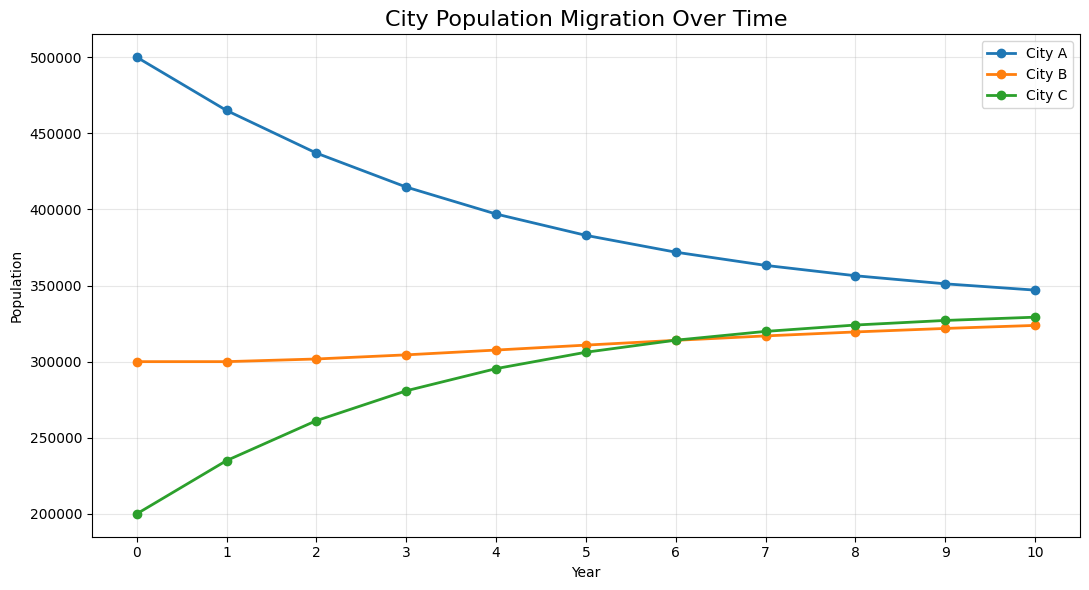

In [ ]:
# ============================================================
# CELL 15: POPULATION EVOLUTION CHART
# ============================================================

years = np.arange(n_years + 1)

plt.figure(figsize=(11, 6))

for i, city in enumerate(cities):
    plt.plot(
        years,
        population_history[:, i],
        marker='o',
        linewidth=2,
        label=city
    )

plt.title("City Population Migration Over Time", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Population")
plt.xticks(years)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

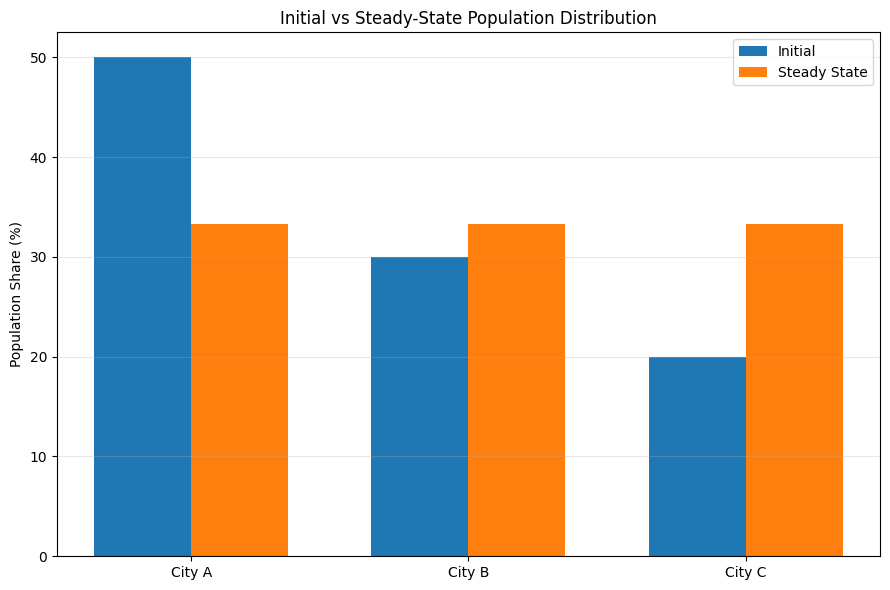

In [ ]:
# ============================================================
# CELL 16: INITIAL VS STEADY-STATE DISTRIBUTION
# ============================================================

x = np.arange(len(cities))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    initial_distribution * 100,
    width,
    label="Initial"
)

plt.bar(
    x + width / 2,
    steady_distribution * 100,
    width,
    label="Steady State"
)

plt.xticks(x, cities)
plt.ylabel("Population Share (%)")
plt.title("Initial vs Steady-State Population Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

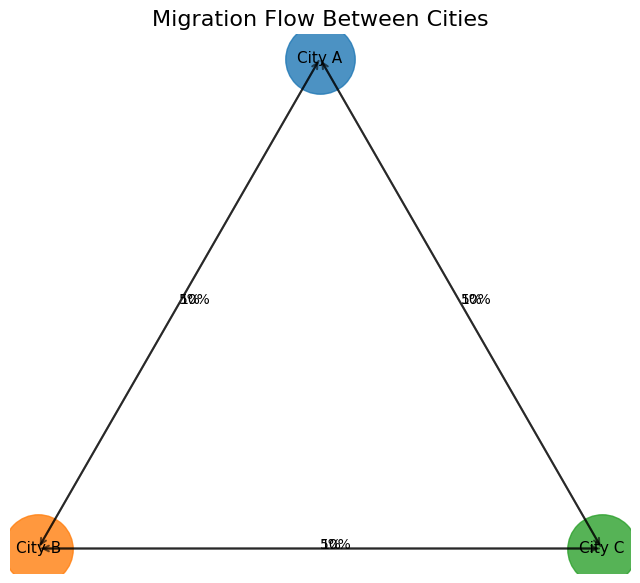

In [ ]:
# ============================================================
# CELL 17: MIGRATION NETWORK
# ============================================================

plt.figure(figsize=(8, 7))

# Positions of cities
positions = {
    0: (0, 1),
    1: (-1, -1),
    2: (1, -1)
}

# Draw cities
for i, city in enumerate(cities):
    x_pos, y_pos = positions[i]

    plt.scatter(
        x_pos,
        y_pos,
        s=2500,
        alpha=0.8
    )

    plt.text(
        x_pos,
        y_pos,
        city,
        ha="center",
        va="center",
        fontsize=11
    )


# Draw migration arrows
for i in range(3):
    for j in range(3):

        if i != j and migration_rate[i, j] > 0:

            x1, y1 = positions[i]
            x2, y2 = positions[j]

            plt.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="->",
                    linewidth=1.5,
                    alpha=0.6
                )
            )

            # Put migration percentage near the middle
            mid_x = (x1 + x2) / 2
            mid_y = (y1 + y2) / 2

            plt.text(
                mid_x,
                mid_y,
                f"{migration_rate[i,j] * 100:.0f}%",
                fontsize=10
            )

plt.title("Migration Flow Between Cities", fontsize=16)
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# CELL 18: FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("       CITY POPULATION MIGRATION MODEL (C3)")
print("=" * 70)

print("\nMathematical Model:")
print("P(n) = M^n P(0)")

print("\nDiagonalization:")
print("M = P D P^(-1)")

print("\nTherefore:")
print("M^n = P D^n P^(-1)")

print("\n" + "-" * 70)

# ------------------------------------------------------------
# Population after n years
# ------------------------------------------------------------

print(f"Population after {n_years} years:")

for i, city in enumerate(cities):

    # Take only the real part
    population = complex(sp.N(P_n[i])).real

    print(
        f"{city:<10}: "
        f"{population:,.2f}"
    )


print("\n" + "-" * 70)

# ------------------------------------------------------------
# Steady-State Distribution
# ------------------------------------------------------------

print("Steady-State Distribution:")

for city, percentage in zip(cities, steady_distribution):

    print(
        f"{city:<10}: "
        f"{percentage * 100:.2f}%"
    )


print("\n" + "-" * 70)

# ------------------------------------------------------------
# Long-Term Population
# ------------------------------------------------------------

print("Long-Term Population:")

for city, population in zip(cities, steady_population):

    print(
        f"{city:<10}: "
        f"{population:,.2f}"
    )


print("\n" + "=" * 70)
print("Project calculation completed successfully!")
print("=" * 70)

       CITY POPULATION MIGRATION MODEL (C3)

Mathematical Model:
P(n) = M^n P(0)

Diagonalization:
M = P D P^(-1)

Therefore:
M^n = P D^n P^(-1)

----------------------------------------------------------------------
Population after 10 years:
City A    : 346,985.09
City B    : 323,805.59
City C    : 329,209.32

----------------------------------------------------------------------
Steady-State Distribution:
City A    : 33.33%
City B    : 33.33%
City C    : 33.33%

----------------------------------------------------------------------
Long-Term Population:
City A    : 333,333.33
City B    : 333,333.33
City C    : 333,333.33

Project calculation completed successfully!


In [ ]:
# ============================================================
# CELL 19: BENCHMARK TEST
# ============================================================

def run_benchmark():
    """
    Small realistic benchmark:
    100,000 people distributed among 3 cities.
    """

    benchmark_population = np.array([
        50000,
        30000,
        20000
    ], dtype=float)

    benchmark_rates = np.array([
        [0.00, 0.05, 0.10],
        [0.10, 0.00, 0.05],
        [0.05, 0.10, 0.00]
    ])

    benchmark_M = build_migration_matrix(
        benchmark_rates
    )

    benchmark_history = calculate_population_history(
        benchmark_M,
        benchmark_population,
        10
    )

    initial_total = benchmark_population.sum()
    final_total = benchmark_history[-1].sum()

    print("Benchmark Test")
    print("=" * 50)

    print(f"Initial population : {initial_total:,.0f}")
    print(f"Final population   : {final_total:,.0f}")

    if np.isclose(initial_total, final_total):
        print("✓ Population conservation test PASSED")
    else:
        print("✗ Population conservation test FAILED")


run_benchmark()

Benchmark Test
Initial population : 100,000
Final population   : 100,000
✓ Population conservation test PASSED
